<a href="https://colab.research.google.com/github/Reileen00/Basic-CV-projects/blob/main/Object_Detection_in_Static_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File ‘yolov3.weights’ already there; not retrieving.

File ‘yolov3.cfg’ already there; not retrieving.
File ‘coco.names’ already there; not retrieving.


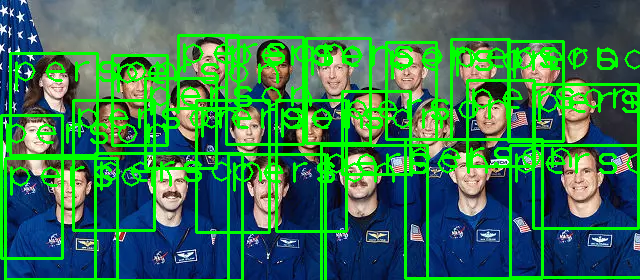

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import for displaying images in Colab

# Download YOLO files if not already present
!wget -nc https://pjreddie.com/media/files/yolov3.weights
!wget -nc https://github.com/pjreddie/darknet/blob/master/cfg/yolov3.cfg?raw=true -O yolov3.cfg
!wget -nc https://github.com/pjreddie/darknet/blob/master/data/coco.names?raw=true -O coco.names

# Load YOLO
net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")

# Load class names
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

layer_names = net.getLayerNames()
# Fix: Flatten the output of getUnconnectedOutLayers() to ensure correct indexing
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

# Load image
img = cv2.imread('/content/1.webp')
height, width, channels = img.shape

# Detecting objects
blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Showing information on the screen
class_ids = []
confidences = []
boxes = []
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            # Object detected
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)
            # Rectangle coordinates
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

font = cv2.FONT_HERSHEY_PLAIN # Define font for text
for i in range(len(boxes)):
    if i in indexes:
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img, label, (x, y + 30), font, 3, (0, 255, 0), 2)

# For displaying images in Colab, use cv2_imshow from google.colab.patches
cv2_imshow(img)
# cv2.imshow("Image", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()